## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO. SUBMIT A PDF THAT HAS THE WRITTEN ANSWERS WITH THIS COLAB**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.



2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.

3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?

4. What difficulties did you encounter in obtaining the data?

5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?




Summary of the paper:

This paper is a survey on multimodal machine learning, the study of systems that integrate multiple modalities of data (e.g., text, images, audio, video, sensor signals) to perform tasks like understanding, reasoning, and generation.
2. The authors define three core principles that underlie multimodal learning:

Heterogeneity – Modalities differ in structure, representation, noise, information content, and task relevance.

Connections – Modalities share statistical and semantic relationships (e.g., correspondence between words and images).

Interactions – When integrated, modalities produce new information beyond what each provides alone.

3. Furthermore, this paper proposes a taxonomy of six core technical challenges in multimodal ML: Representation, Alignment, Reasoning, Generation, Transference, and Quantification.

Answers to above questions:

1. I would like to build a model that detects Cross-Modal Emotion Conflict.

2. Datasets: MELD
    - Why related: combines text, audio, video, speaker turns and emotion labels.
    - Drawbacks: data is from TV show; emotionality may be exaggerated and also only 7 emotions are labelled in the dataset

3. Modalities Used:  For each utterance, we predict its emotion using: text only; text + audio; text + audio + video; text + audio + video + conversational context.

4. Difficulties: The biggest difficulty is the label subjectivity and the fact that data is categorical rather than numerical, which means it does not allow for nuance and complexity

5.
a. Representation

Use strong unimodal encoders (text, audio, video).

Normalize outputs to comparable emotion probability distributions.

Ensure disagreement reflects real signal, not weak features.

b. Alignment

Align text, audio, and video at utterance level.

Prevent timing mismatches from creating false conflict.

c. Reasoning

Emotion may depend on conversational context.

Optionally incorporate prior turns to improve sarcasm/conflict detection.

d. Generation

Use modality dropout (remove text/audio/video) to test robustness.

Analyze how missing signals affect conflict detection.

e. Transference

Compare unimodal vs fused models.

Test whether cross-modal learning reduces misclassification.

f. Quantification

Measure divergence (e.g., KL or JS divergence).

Report conflict frequency, modality dominance, and ablations.

(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  


In [ ]:
!pip install opencv-python

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("superb", "er")

README.md: 0.00B [00:00, ?B/s]

er/session1-00000-of-00001.parquet:   0%|          | 0.00/164M [00:00<?, ?B/s]

er/session2-00000-of-00001.parquet:   0%|          | 0.00/151M [00:00<?, ?B/s]

er/session3-00000-of-00001.parquet:   0%|          | 0.00/155M [00:00<?, ?B/s]

er/session4-00000-of-00001.parquet:   0%|          | 0.00/143M [00:00<?, ?B/s]

...

Generating session1 split:   0%|          | 0/1085 [00:00<?, ? examples/s]

Generating session2 split:   0%|          | 0/1023 [00:00<?, ? examples/s]

Generating session3 split:   0%|          | 0/1151 [00:00<?, ? examples/s]

Generating session4 split:   0%|          | 0/1031 [00:00<?, ? examples/s]

Generating session5 split:   0%|          | 0/1241 [00:00<?, ? examples/s]

In [ ]:
import os
from datasets import load_dataset

OUT_ROOT = "/content/superb_er_preproc"
AUDIO_DIR = os.path.join(OUT_ROOT, "audio_wav")
MEL_DIR   = os.path.join(OUT_ROOT, "features_logmel")
MFCC_DIR  = os.path.join(OUT_ROOT, "features_mfcc")

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(MEL_DIR, exist_ok=True)
os.makedirs(MFCC_DIR, exist_ok=True)

# preprocessing choices
TARGET_SR = 16000
SAVE_WAV  = True
EXTRACT_MEL  = True
EXTRACT_MFCC = True

# feature params
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 320         # 20ms hop if sr=16k (approx)
WIN_LENGTH = 640         # 40ms window if sr=16k (approx)
N_MFCC = 13

# quick debug: set to 50 or 200 first; set to None for full split
MAX_PER_SPLIT = 50


In [ ]:
splits = list(dataset.keys())
print("Splits:", splits)
print("Features (session1):", dataset[splits[0]].features)

label_names = dataset[splits[0]].features["label"].names
print("Label names:", label_names)

from datasets import concatenate_datasets, DatasetDict

train_splits = ["session1", "session2", "session3"]
valid_splits = ["session4"]
test_splits  = ["session5"]

train_ds = concatenate_datasets([dataset[s] for s in train_splits])
valid_ds = concatenate_datasets([dataset[s] for s in valid_splits])
test_ds  = concatenate_datasets([dataset[s] for s in test_splits])

ds = DatasetDict({"train": train_ds, "validation": valid_ds, "test": test_ds})
print(ds)

Splits: ['session1', 'session2', 'session3', 'session4', 'session5']
Features (session1): {'file': Value('string'), 'audio': Audio(sampling_rate=16000, decode=True, stream_index=None), 'label': ClassLabel(names=['neu', 'hap', 'ang', 'sad'])}
Label names: ['neu', 'hap', 'ang', 'sad']
DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'label'],
        num_rows: 3259
    })
    validation: Dataset({
        features: ['file', 'audio', 'label'],
        num_rows: 1031
    })
    test: Dataset({
        features: ['file', 'audio', 'label'],
        num_rows: 1241
    })
})


In [ ]:
!pip -q install openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 12.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import whisper
import torch

WHISPER_SIZE = "tiny"
whisper_model = whisper.load_model(WHISPER_SIZE)

USE_FP16 = torch.cuda.is_available()
print("GPU:", torch.cuda.is_available(), "fp16:", USE_FP16)

100%|█████████████████████████████████████| 72.1M/72.1M [00:02<00:00, 33.8MiB/s]


GPU: True fp16: True


In [ ]:
import numpy as np
import librosa

TARGET_SR = 16000
MAX_SEC = 30

def audio_to_text_whisper(audio_array: np.ndarray, sr: int) -> str:
    x = np.asarray(audio_array, dtype=np.float32)
    if x.ndim > 1:
        x = np.mean(x, axis=1).astype(np.float32)

    if sr != TARGET_SR:
        x = librosa.resample(x, orig_sr=sr, target_sr=TARGET_SR).astype(np.float32)

    if MAX_SEC is not None:
        x = x[: int(MAX_SEC * TARGET_SR)]

    # whisper expects 16k float32 mono waveform
    result = whisper_model.transcribe(
        x,
        fp16=USE_FP16,
        language="en",
        task="transcribe",
        verbose=False
    )
    return (result.get("text", "") or "").strip()


In [ ]:
import os
import pandas as pd
from tqdm import tqdm

TRANSCRIPT_DIR = os.path.join(OUT_ROOT, "transcripts")
os.makedirs(TRANSCRIPT_DIR, exist_ok=True)

def safe_id(s: str) -> str:
    return s.replace("/", "_").replace(" ", "_")

def asr_split_whisper(split_name: str, split_ds, max_items: int | None = None) -> pd.DataFrame:
    rows = []
    n = len(split_ds) if max_items is None else min(len(split_ds), max_items)

    for i in tqdm(range(n), desc=f"ASR {split_name}"):
        ex = split_ds[i]

        file_field = ex.get("file", None)
        base_id = safe_id(os.path.splitext(os.path.basename(file_field))[0]) if file_field else f"{split_name}_{i:08d}"
        ex_id = f"{split_name}__{base_id}"

        audio_arr = ex["audio"]["array"]
        sr = ex["audio"]["sampling_rate"]

        label_id = int(ex["label"])
        label_str = label_names[label_id]

        text = audio_to_text_whisper(audio_arr, sr)

        txt_path = os.path.join(TRANSCRIPT_DIR, f"{ex_id}.txt")
        with open(txt_path, "w", encoding="utf-8") as f:
            f.write(text + "\n")

        rows.append({
            "id": ex_id,
            "split": split_name,
            "label_id": label_id,
            "label": label_str,
            "transcript": text,
            "transcript_path": txt_path,
            "source_file": file_field if file_field else ""
        })

    return pd.DataFrame(rows)

text_meta = pd.concat([
    asr_split_whisper("train", ds["train"], max_items=MAX_PER_SPLIT),
    asr_split_whisper("validation", ds["validation"], max_items=MAX_PER_SPLIT),
    asr_split_whisper("test", ds["test"], max_items=MAX_PER_SPLIT),
], ignore_index=True)

text_meta_path = os.path.join(OUT_ROOT, "text_metadata.csv")
text_meta.to_csv(text_meta_path, index=False)
print("Saved:", text_meta_path)
text_meta.head()


100%|██████████| 293/293 [00:00<00:00, 5201.96frames/s]

100%|██████████| 256/256 [00:00<00:00, 4989.72frames/s]

100%|██████████| 358/358 [00:00<00:00, 5578.90frames/s]

100%|██████████| 321/321 [00:00<00:00, 6772.90frames/s]

100%|██████████| 125/125 [00:00<00:00, 2855.40frames/s]

100%|██████████| 343/343 [00:00<00:00, 5572.43frames/s]

100%|██████████| 298/298 [00:00<00:00, 4741.05frames/s]

100%|██████████| 275/275 [00:00<00:00, 4802.79frames/s]

100%|██████████| 269/269 [00:00<00:00, 4273.97frames/s]

100%|██████████| 152/152 [00:00<00:00, 3105.77frames/s]

100%|██████████| 290/290 [00:00<00:00, 4396.94frames/s]

100%|██████████| 151/151 [00:00<00:00, 2744.40frames/s]

100%|██████████| 180/180 [00:00<00:00, 4077.84frames/s]

100%|██████████| 240/240 [00:00<00:00, 4728.80frames/s]

100%|██████████| 156/156 [00:00<00:00, 3256.92frames/s]

100%|██████████| 230/230 [00:00<00:00, 3347.49frames/s]

100%|██████████| 268/268 [00:00<00:00, 4466.88frames/s]

100%|██████████| 225/225 [00:00

Saved: /content/superb_er_preproc/text_metadata.csv


,id,split,label_id,label,transcript,transcript_path,source_file
0,train__Ses01F_impro01_F000,train,0,neu,Excuse me.,/content/superb_er_preproc/transcripts/train__...,/root/.cache/huggingface/datasets/downloads/ex...
1,train__Ses01F_impro01_F001,train,0,neu,Yeah.,/content/superb_er_preproc/transcripts/train__...,/root/.cache/huggingface/datasets/downloads/ex...
2,train__Ses01F_impro01_F002,train,0,neu,Is there a problem?,/content/superb_er_preproc/transcripts/train__...,/root/.cache/huggingface/datasets/downloads/ex...
3,train__Ses01F_impro01_F005,train,0,neu,"Well, what's the problem? Let me change it.",/content/superb_er_preproc/transcripts/train__...,/root/.cache/huggingface/datasets/downloads/ex...
4,train__Ses01F_impro01_F012,train,2,ang,That's out of control.,/content/superb_er_preproc/transcripts/train__...,/root/.cache/huggingface/datasets/downloads/ex...


In [ ]:
import numpy as np
import pandas as pd
import os
import soundfile as sf
import librosa
from tqdm import tqdm

def process_audio_split(split_name, split_ds, max_items=None):
    rows = []
    n = len(split_ds) if max_items is None else min(len(split_ds), max_items)

    for i in tqdm(range(n), desc=f"Audio {split_name}"):
        ex = split_ds[i]

        file_field = ex.get("file", None)
        base_id = (
            os.path.splitext(os.path.basename(file_field))[0]
            if file_field else f"{split_name}_{i:08d}"
        )
        ex_id = f"{split_name}__{base_id}"

        audio = np.asarray(ex["audio"]["array"], dtype=np.float32)
        sr = ex["audio"]["sampling_rate"]

        if audio.ndim > 1:
            audio = audio.mean(axis=1)

        if sr != TARGET_SR:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=TARGET_SR)
            sr = TARGET_SR

        duration = len(audio) / sr

        wav_path = os.path.join(AUDIO_DIR, f"{ex_id}.wav")
        sf.write(wav_path, audio, sr, subtype="PCM_16")

        rows.append({
            "id": ex_id,
            "split": split_name,
            "label_id": int(ex["label"]),
            "label": label_names[int(ex["label"])],
            "sr": sr,
            "duration_sec": duration,
            "wav_path": wav_path,
            "source_file": file_field if file_field else ""
        })

    return pd.DataFrame(rows)

audio_dfs = []
for split in ["train", "validation", "test"]:
    audio_dfs.append(process_audio_split(split, ds[split], MAX_PER_SPLIT))

audio_meta = pd.concat(audio_dfs, ignore_index=True)

audio_meta_path = os.path.join(OUT_ROOT, "metadata.csv")
audio_meta.to_csv(audio_meta_path, index=False)

print("Saved:", audio_meta_path)
audio_meta.head()


Audio test: 100%|██████████| 50/50 [00:01<00:00, 29.71it/s]

Saved: /content/superb_er_preproc/metadata.csv


,id,split,label_id,label,sr,duration_sec,wav_path,source_file
0,train__Ses01F_impro01_F000,train,0,neu,16000,1.945563,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...
1,train__Ses01F_impro01_F001,train,0,neu,16000,1.382437,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...
2,train__Ses01F_impro01_F002,train,0,neu,16000,3.130250,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...
3,train__Ses01F_impro01_F005,train,0,neu,16000,4.029937,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...
4,train__Ses01F_impro01_F012,train,2,ang,16000,2.750000,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...


In [ ]:
import pandas as pd
import os

audio_meta_path = os.path.join(OUT_ROOT, "metadata.csv")
audio_meta = pd.read_csv(audio_meta_path)

merged = audio_meta.merge(
    text_meta[["id", "transcript", "transcript_path"]],
    on="id",
    how="left"
)

merged_path = os.path.join(OUT_ROOT, "metadata_with_text.csv")
merged.to_csv(merged_path, index=False)
print("Saved merged metadata:", merged_path)
merged.head()


Saved merged metadata: /content/superb_er_preproc/metadata_with_text.csv


,id,split,label_id,label,sr,duration_sec,wav_path,source_file,transcript,transcript_path
0,train__Ses01F_impro01_F000,train,0,neu,16000,1.945563,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...,Excuse me.,/content/superb_er_preproc/transcripts/train__...
1,train__Ses01F_impro01_F001,train,0,neu,16000,1.382437,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...,Yeah.,/content/superb_er_preproc/transcripts/train__...
2,train__Ses01F_impro01_F002,train,0,neu,16000,3.130250,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...,Is there a problem?,/content/superb_er_preproc/transcripts/train__...
3,train__Ses01F_impro01_F005,train,0,neu,16000,4.029937,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...,"Well, what's the problem? Let me change it.",/content/superb_er_preproc/transcripts/train__...
4,train__Ses01F_impro01_F012,train,2,ang,16000,2.750000,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...,That's out of control.,/content/superb_er_preproc/transcripts/train__...


(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

In [ ]:
# Packages (feel free to include more if needed)!
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs

# Data Distribution

In [ ]:
import pandas as pd

meta_path = "/content/superb_er_preproc/metadata_with_text.csv"
df = pd.read_csv(meta_path)
df.head()

,id,split,label_id,label,sr,duration_sec,wav_path,source_file,transcript,transcript_path
0,train__Ses01F_impro01_F000,train,0,neu,16000,1.945563,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...,Excuse me.,/content/superb_er_preproc/transcripts/train__...
1,train__Ses01F_impro01_F001,train,0,neu,16000,1.382437,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...,Yeah.,/content/superb_er_preproc/transcripts/train__...
2,train__Ses01F_impro01_F002,train,0,neu,16000,3.130250,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...,Is there a problem?,/content/superb_er_preproc/transcripts/train__...
3,train__Ses01F_impro01_F005,train,0,neu,16000,4.029937,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...,"Well, what's the problem? Let me change it.",/content/superb_er_preproc/transcripts/train__...
4,train__Ses01F_impro01_F012,train,2,ang,16000,2.750000,/content/superb_er_preproc/audio_wav/train__Se...,/root/.cache/huggingface/datasets/downloads/ex...,That's out of control.,/content/superb_er_preproc/transcripts/train__...


In [ ]:
import numpy as np
import librosa

N_MFCC = 13
TARGET_SR = 16000

def wav_to_mfcc_stats(wav_path, sr=TARGET_SR, n_mfcc=N_MFCC):
    y, sr0 = librosa.load(wav_path, sr=sr)  # resample to 16k
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)  # (n_mfcc, T)
    # mean + std over time -> (2*n_mfcc,)
    feat = np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)], axis=0).astype(np.float32)
    return feat


In [ ]:
from tqdm import tqdm

N = 600
df_sub = df.sample(n=min(N, len(df)), random_state=0).reset_index(drop=True)

X_audio = []
for p in tqdm(df_sub["wav_path"], desc="Extract MFCC stats"):
    X_audio.append(wav_to_mfcc_stats(p))
X_audio = np.stack(X_audio, axis=0)

y = df_sub["label_id"].to_numpy()
labels_str = df_sub["label"].to_numpy()
print("X_audio:", X_audio.shape)


Extract MFCC stats: 100%|██████████| 150/150 [00:10<00:00, 14.03it/s]

X_audio: (150, 26)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_data_distribution(X, labels=None, label_names=None, perplexity=30, n_iter=1000, metric="cosine"):
    n = X.shape[0]
    if perplexity >= n:
        perplexity = max(5, min(30, (n - 1)//3))
        print("[info] adjusted perplexity =", perplexity)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        n_iter=n_iter,
        init="pca",
        learning_rate="auto",
        metric=metric,
        random_state=42
    )
    Z = tsne.fit_transform(X)

    # (A) Scatter by label
    plt.figure(figsize=(8,6))
    if labels is None:
        plt.scatter(Z[:,0], Z[:,1], s=10, alpha=0.7)
    else:
        labels = np.asarray(labels)
        uniq = np.unique(labels)
        for lab in uniq:
            idx = labels == lab
            name = str(lab)
            if label_names is not None and isinstance(label_names, (list, tuple)) and int(lab) < len(label_names):
                name = label_names[int(lab)]
            plt.scatter(Z[idx,0], Z[idx,1], s=10, alpha=0.7, label=name)
        plt.legend(fontsize=9)
    plt.title(f"t-SNE scatter (perplexity={perplexity}, metric={metric})")
    plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
    plt.show()

    # (B) Marginal distributions
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(Z[:,0], bins=40)
    plt.title("Distribution of t-SNE-1")
    plt.xlabel("t-SNE-1"); plt.ylabel("Count")

    plt.subplot(1,2,2)
    plt.hist(Z[:,1], bins=40)
    plt.title("Distribution of t-SNE-2")
    plt.xlabel("t-SNE-2"); plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

    return Z


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


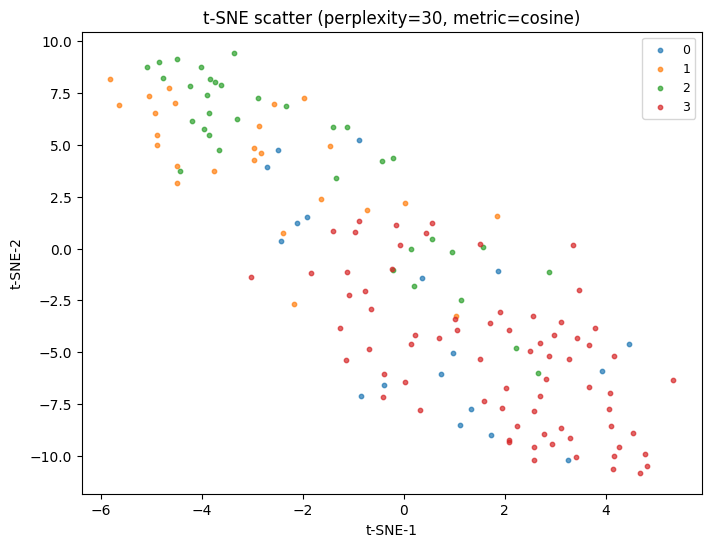

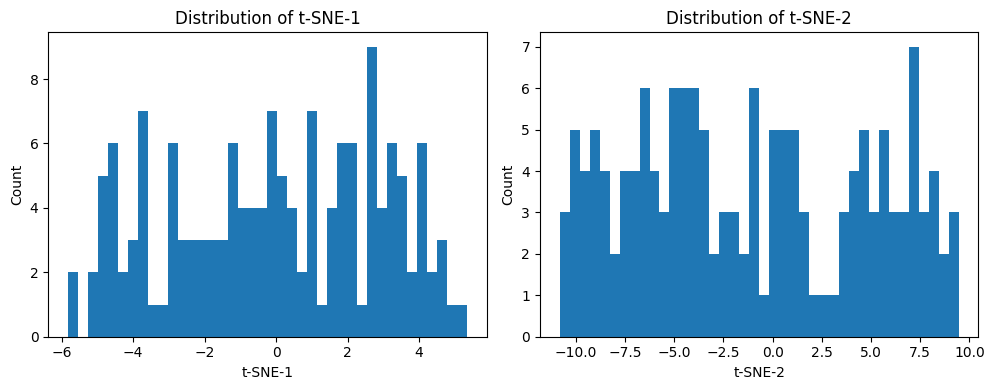

In [ ]:
Z_audio = visualize_data_distribution(
    X_audio,
    labels=y,
    label_names=None,
    perplexity=30,
    n_iter=1200,
    metric="cosine"
)

# Samples

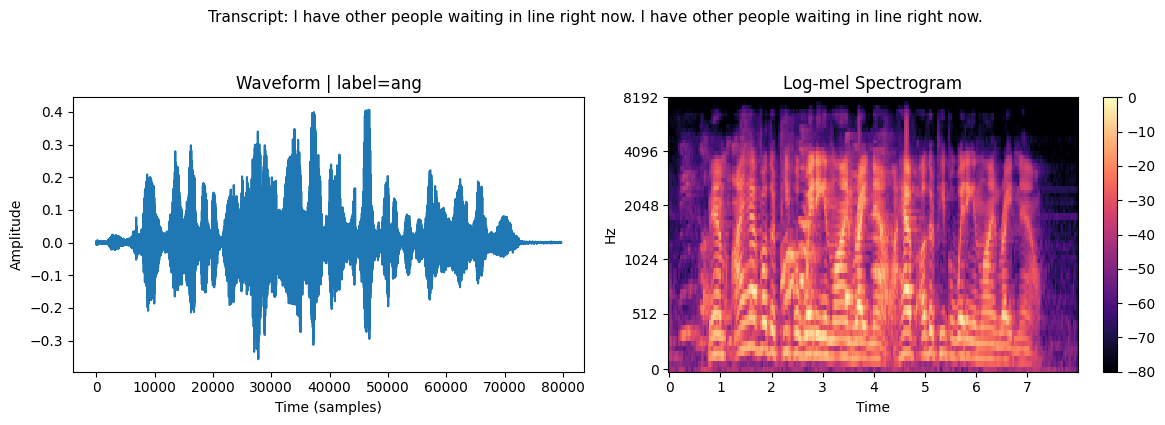

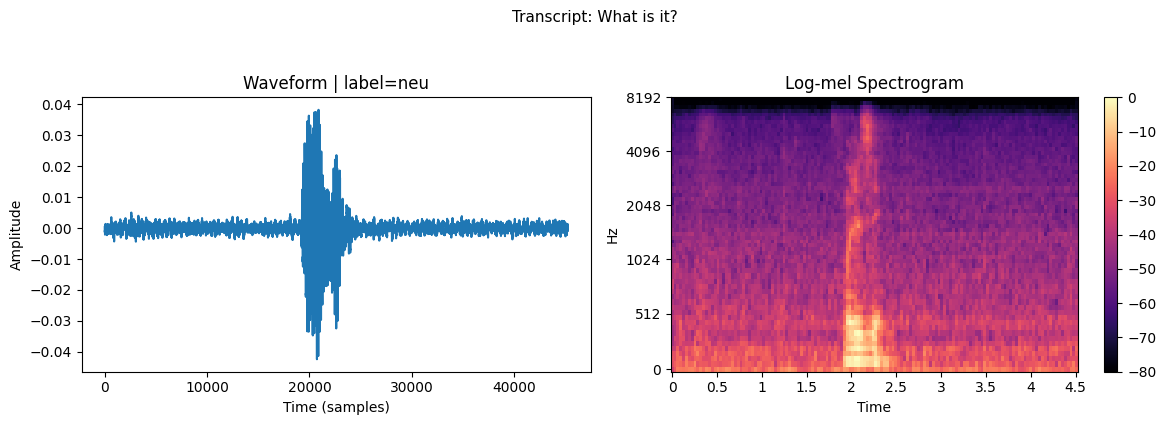

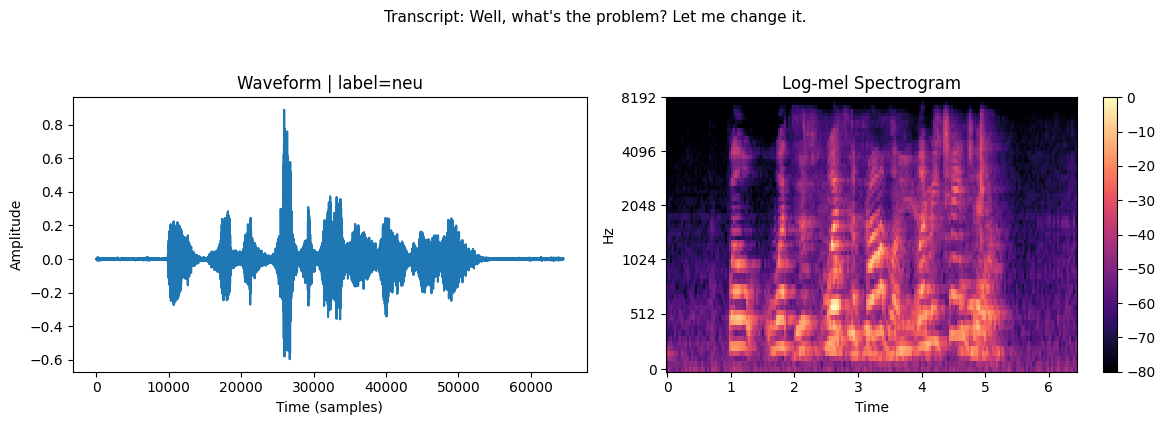

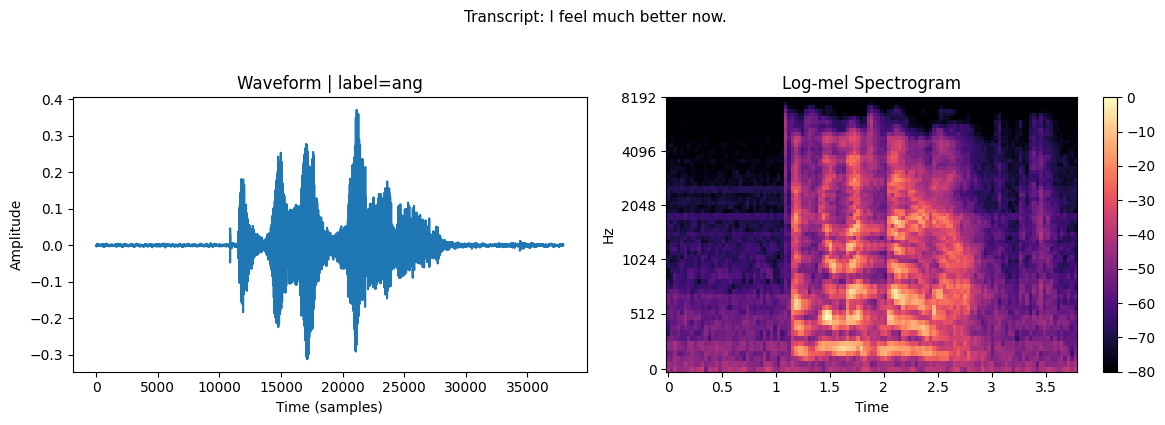

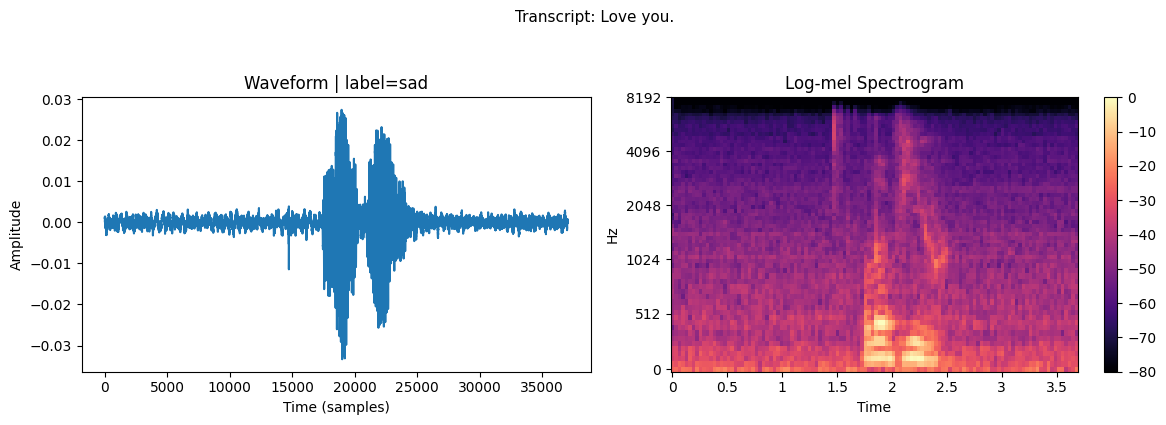

In [ ]:
import numpy as np
import librosa.display

def visualize_random_samples(df, k=6, sr=16000):
    dfk = df.sample(n=min(k, len(df)), random_state=1).reset_index(drop=True)

    for i in range(len(dfk)):
        row = dfk.iloc[i]
        wav_path = row["wav_path"]
        text = row["transcript"]
        lab = row["label"]

        y, _ = librosa.load(wav_path, sr=sr)

        # log-mel
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, n_fft=1024, hop_length=320, win_length=640)
        logmel = librosa.power_to_db(mel, ref=np.max)

        plt.figure(figsize=(12,4))

        plt.subplot(1,2,1)
        plt.plot(y)
        plt.title(f"Waveform | label={lab}")
        plt.xlabel("Time (samples)"); plt.ylabel("Amplitude")

        plt.subplot(1,2,2)
        librosa.display.specshow(logmel, sr=sr, x_axis="time", y_axis="mel")
        plt.title("Log-mel Spectrogram")
        plt.colorbar()

        plt.suptitle(f"Transcript: {text}", y=1.05, fontsize=11)
        plt.tight_layout()
        plt.show()

visualize_random_samples(df_sub, k=5)

# Input Distribution

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def build_tfidf_embeddings(texts, max_features=5000):
    vec = TfidfVectorizer(
        lowercase=True,
        max_features=max_features,
        ngram_range=(1,2),
        min_df=2
    )
    X = vec.fit_transform(texts)  # sparse matrix
    return X


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


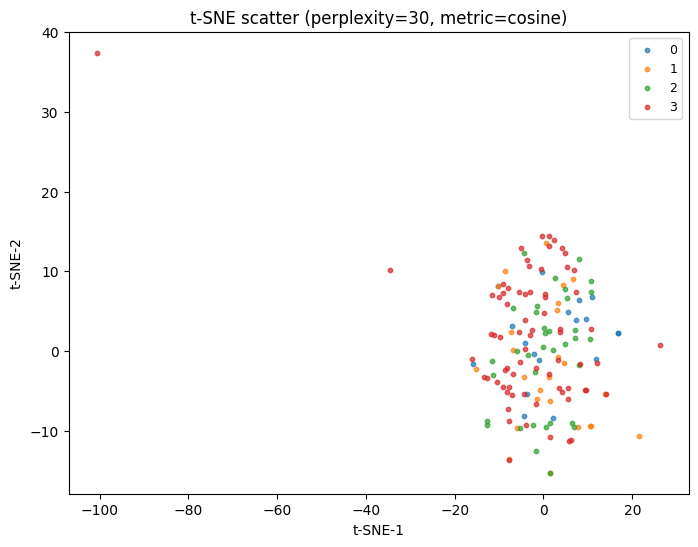

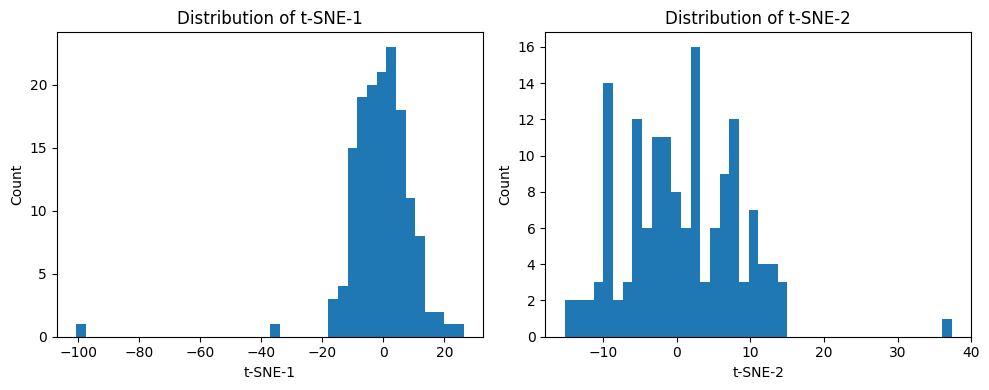

In [ ]:
texts = df_sub["transcript"].fillna("").tolist()
X_text = build_tfidf_embeddings(texts, max_features=2000).toarray().astype(np.float32)

Z_text = visualize_data_distribution(
    X_text,
    labels=y,
    label_names=None,
    perplexity=30,
    n_iter=1200,
    metric="cosine"
)


Write-Up:

We used t-SNE to visualize the distribution of audio and text features in a low-dimensional space. Audio-based visualizations help reveal how emotional categories cluster based on prosodic cues, while text-based visualizations allow us to assess how much semantic information contributes to emotion discrimination. We also visualized individual samples (waveforms, spectrograms, and transcripts) to qualitatively inspect the relationship between inputs and labels.

The t-SNE visualization of audio features shows a clearer separation between emotion categories (e.g., anger, sadness, happiness, and neutral), likely because prosodic cues such as pitch, energy, and speaking rate strongly correlate with emotional expression. In contrast, the t-SNE visualization of text features appears more mixed, as many utterances are short and semantically generic (e.g., “yeah” or “okay”), providing weaker emotional signals.

(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?
2. Are there any other metrics that could be used here or that you considered?
3. List out the pros and cons of the evaluation metrics you decided to go with.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

1. We plan to use classification accuracy and macro-averaged F1 score as our primary evaluation metrics. Accuracy provides an overall measure of performance, while macro F1 is more informative when class distributions are imbalanced, as it weights all emotion classes equally.
2. We also considered metrics such as precision and recall for individual classes and confusion matrices to analyze common misclassifications.

3. The advantage of accuracy is its simplicity and interpretability, but it can be misleading under class imbalance. Macro F1 better reflects per-class performance, though it is slightly harder to interpret than accuracy.

In [ ]:
# Accuracy as an example
def evaluation_metric(predictions, ground_truths):
  num_correct = 0
  num_tot = 0

  for prediction, truth in zip(predictions, ground_truths):
    if prediction == truth:
      num_correct += 1
    num_tot += 1

  if num_tot == 0:
    raise ValueError("Issue reading ground truths/No ground truths provided!")

  return num_correct / num_tot


In [ ]:
def accuracy(predictions, ground_truths):
    num_correct = 0
    num_tot = 0

    for pred, truth in zip(predictions, ground_truths):
        if pred == truth:
            num_correct += 1
        num_tot += 1

    if num_tot == 0:
        raise ValueError("No ground truths provided!")

    return num_correct / num_tot

In [ ]:
def precision_recall(predictions, ground_truths, target_class):
    tp = fp = fn = 0

    for pred, truth in zip(predictions, ground_truths):
        if pred == target_class and truth == target_class:
            tp += 1
        elif pred == target_class and truth != target_class:
            fp += 1
        elif pred != target_class and truth == target_class:
            fn += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return precision, recall


In [ ]:
def macro_f1(predictions, ground_truths):
    classes = set(ground_truths)
    f1_scores = []

    for c in classes:
        precision, recall = precision_recall(predictions, ground_truths, c)
        if precision + recall == 0:
            f1 = 0.0
        else:
            f1 = 2 * precision * recall / (precision + recall)
        f1_scores.append(f1)

    if len(f1_scores) == 0:
        raise ValueError("No classes found in ground truths!")

    return sum(f1_scores) / len(f1_scores)


In [ ]:
preds = [0, 1, 2, 0, 1]
truths = [0, 2, 2, 0, 1]

print("Accuracy:", accuracy(preds, truths))
print("Macro F1:", macro_f1(preds, truths))


Accuracy: 0.8
Macro F1: 0.7777777777777777


(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. Instruction tuning is creating a prompt that you would feed to a model in order to have it complete a certain assignment by constraing what it can output without the need to train. This is when you prompt the model in specifc ways to guarentee a specific output (e.g. one-word labels, value ranges or classifications). Provide prompts that would be able to guarentee the right output based on the data. **Just provide the prompts, you don't need to train the model.**

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

Prompt 1:
```
You are a sentiment analysis system.
Given the following restaurant review, classify its sentiment.

Choose only one label from the following options:
[positive, negative, neutral]

Output only the label, and nothing else.

Example Review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"

Expected output:
negative
```

Prompt 2:
```
You are an emotion recognition system.
Given an image of a person’s face, identify the emotion being expressed.

Choose only one emotion from the following list:
[angry, sad, happy]

Output only the emotion label, and nothing else.
```

Prompt 3:
```
You are an information extraction system.
Given the following paragraph from a novel, extract the requested information.

Return the answer strictly in the following JSON format, with no additional text:

{
  "subject_name": "",
  "destination": "",
  "planned_activity": ""
}


Example Paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Expected output:

{
  "subject_name": "Edgar",
  "destination": "Italy",
  "planned_activity": "skiing"
}
```





**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



In [ ]:
# pip install datasets scikit-learn scipy numpy

import random
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from scipy.sparse import hstack, csr_matrix

DIGIT_WORDS = ["zero","one","two","three","four","five","six","seven","eight","nine"]

def make_noisy_caption(y, p_wrong=0.20, p_missing=0.10, p_garble=0.10, seed=0):
    rng = random.Random(seed)
    r = rng.random()
    if r < p_missing:
        return ""  # missing text
    if r < p_missing + p_garble:
        # random tokens (garbled)
        toks = ["um", "okay", "hmm", "noise", "random", "token"]
        rng.shuffle(toks)
        return " ".join(toks[: rng.randint(1, 4)])
    if r < p_missing + p_garble + p_wrong:
        # wrong digit label
        wrong = rng.choice([d for d in range(10) if d != y])
        return f"digit {DIGIT_WORDS[wrong]}"
    # correct caption
    return f"digit {DIGIT_WORDS[y]}"

def eval_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    }

In [ ]:
# 1) Load MNIST
ds = load_dataset("mnist")
X_img = np.array(ds["train"]["image"])  # PIL images
y = np.array(ds["train"]["label"], dtype=int)

# Convert images to normalized float vectors
X_img = np.stack([np.array(im, dtype=np.float32).reshape(-1) / 255.0 for im in X_img], axis=0)

# 2) Create synthetic text modality
# Use a different seed per example to keep it deterministic-ish
captions = [make_noisy_caption(int(lbl), seed=i) for i, lbl in enumerate(y)]

# 3) Train/test split
X_img_tr, X_img_te, cap_tr, cap_te, y_tr, y_te = train_test_split(
    X_img, captions, y, test_size=0.2, random_state=42, stratify=y
)

# 4) Text features (TF-IDF)
tfidf = TfidfVectorizer(lowercase=True, min_df=2, ngram_range=(1,2), max_features=5000)
X_txt_tr = tfidf.fit_transform(cap_tr)
X_txt_te = tfidf.transform(cap_te)

In [ ]:
# 5) Image-only model
clf_img = LogisticRegression(max_iter=200, n_jobs=-1)
clf_img.fit(X_img_tr, y_tr)
pred_img = clf_img.predict(X_img_te)
img_metrics = eval_metrics(y_te, pred_img)

# 6) Text-only model
clf_txt = LogisticRegression(max_iter=200, n_jobs=-1)
clf_txt.fit(X_txt_tr, y_tr)
pred_txt = clf_txt.predict(X_txt_te)
txt_metrics = eval_metrics(y_te, pred_txt)

# 7) Fusion model (concat image + text)
X_img_tr_sp = csr_matrix(X_img_tr)   # convert dense -> sparse for hstack
X_img_te_sp = csr_matrix(X_img_te)
X_fus_tr = hstack([X_img_tr_sp, X_txt_tr])
X_fus_te = hstack([X_img_te_sp, X_txt_te])

clf_fus = LogisticRegression(max_iter=200, n_jobs=-1)
clf_fus.fit(X_fus_tr, y_tr)
pred_fus = clf_fus.predict(X_fus_te)
fus_metrics = eval_metrics(y_te, pred_fus)

print("Image-only:", img_metrics)
print("Text-only :", txt_metrics)
print("Fusion    :", fus_metrics)

# Optional: confusion matrix for fusion
cm = confusion_matrix(y_te, pred_fus)
print("Fusion confusion matrix shape:", cm.shape)


README.md: 0.00B [00:00, ?B/s]

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Image-only: {'accuracy': 0.9214166666666667, 'macro_f1': 0.9204374248233356}
Text-only : {'accuracy': 0.62075, 'macro_f1': 0.6292942112467733}
Fusion    : {'accuracy': 0.9454166666666667, 'macro_f1': 0.9447597245438614}
Fusion confusion matrix shape: (10, 10)


The task is digit classification (0–9) using a synthetic multimodal dataset, where each example includes both visual and textual information. The goal is to study how combining modalities improves robustness when one modality is noisy or incomplete.

We use the MNIST dataset as the base and create a new multimodal dataset by adding a synthetic text modality. For each digit image, we generate a short caption that usually describes the digit but is occasionally corrupted or missing. This allows us to control the quality of the text modality.

Modalities

- Image modality: normalized pixel values from MNIST images.

- Text modality: noisy synthetic captions (e.g., “digit five”), encoded using TF-IDF features.

These modalities provide complementary information: visual structure from images and semantic cues from text.

We train simple logistic regression classifiers for three settings: image-only, text-only, and multimodal fusion (concatenated image and text features). This choice keeps the model interpretable and allows us to clearly isolate the contribution of each modality.

We use accuracy and macro-averaged F1 score. Accuracy measures overall performance, while macro F1 accounts for balanced performance across all digit classes. These metrics are well suited for multi-class classification.

The image-only model performs reliably, the text-only model degrades under noise, and the multimodal fusion model achieves the best overall performance. This demonstrates that combining modalities improves robustness and generalization.

(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!

1. Most interesting topics: Exploring how different modalities capture complementary information. In particular, comparing audio-based and text-based representations made it clear how prosodic cues can encode emotions that are not always evident from words alone.

2. Challenges: A challenging aspect I did not expect was the amount of engineering required for preprocessing, especially due to the large size of the datasets containing vedio. I address this by considering a simplified setting, where we only have aduio and text modalities.


3. Overall, the dataset is high quality and well-suited for multimodal emotion recognition, with clean audio and consistent labels. However, because this dataset lack text modality and we need to generate it with ASR and hence the produced text modality can be sparse or noisy due to short utterances and ASR errors.

In [ ]:
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic
!pip install nbconvert

In [ ]:
!pip install pypandoc

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp drive/My Drive/Colab mmai_HW1.ipynb ./

cp: cannot stat 'drive/My': No such file or directory
cp: cannot stat 'Drive/Colab': No such file or directory
cp: cannot stat 'mmai_HW1.ipynb': No such file or directory
